# Vision Transformer (ViT) for Sign Language Detection

This notebook trains a Vision Transformer model for real-time sign language detection using pose estimation.

## Architecture Overview
- **Input**: 21 hand keypoints from MediaPipe (x, y, z coordinates)
- **Preprocessing**: Reshape 21 keypoints → 7×7 grid (2D patch representation)
- **Model**: Vision Transformer with self-attention mechanism
- **Output**: Gesture class prediction

In [19]:
import csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## Configuration

In [20]:
# Paths
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier_vit.h5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier_vit.tflite'

# Model configuration
NUM_CLASSES = 10  # Updated to match actual dataset classes (0-9)
IMAGE_SIZE = 7  # 7x7 grid for 21 keypoints
EMBED_DIM = 64
NUM_HEADS = 4
MLP_HIDDEN = 128
TRANSFORMER_LAYERS = 2

## Data Loading and Preprocessing

In [21]:
# Load dataset
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

print(f"Raw data shape: {X_dataset.shape}")
print(f"Labels shape: {y_dataset.shape}")
print(f"Number of classes: {len(np.unique(y_dataset))}")

Raw data shape: (8788, 42)
Labels shape: (8788,)
Number of classes: 10


## Keypoint to 2D Grid Preprocessing

In [22]:
def keypoints_to_grid(landmark_list):
    """
    Convert 21 hand keypoints to 7x7x3 grid representation.
    Uses same normalization as ViT classifier for consistency.
    
    Args:
        landmark_list: Flattened keypoints (42 values) or (21, 2) array
    
    Returns:
        grid: 7x7x3 numpy array
    """
    # Reshape to (21, 2) if flattened
    if len(landmark_list.shape) == 1:
        keypoints = landmark_list.reshape(21, 2)
    else:
        keypoints = landmark_list
    
    # Normalize keypoints like the MLP classifier (relative to wrist + global normalization)
    # Convert to relative coordinates
    keypoints_relative = keypoints - keypoints[0]  # Center around wrist
    
    # Flatten and normalize by max absolute value (same as MLP preprocessing)
    flattened = keypoints_relative.flatten()
    max_value = np.max(np.abs(flattened))
    if max_value > 0:
        flattened_normalized = flattened / max_value
    else:
        flattened_normalized = flattened
    
    # Reshape back to (21, 2) for grid mapping
    keypoints_normalized = flattened_normalized.reshape(21, 2)
    
    # Add z coordinate (0)
    z_coords = np.zeros((21, 1))
    keypoints_normalized = np.hstack([keypoints_normalized, z_coords])
    
    # Create 7x7 grid
    grid = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
    
    # Map keypoints to grid positions (hand topology)
    keypoint_positions = [
        (0, 0), (0, 3), (0, 6),  # Wrist, middle, pinky base
        (1, 1), (1, 3), (1, 5),  # Thumb, middle, pinky
        (2, 1), (2, 3), (2, 5),  # Index, middle, pinky PIP
        (3, 1), (3, 3), (3, 5),  # Index, middle, pinky DIP
        (4, 0), (4, 2), (4, 4), (4, 6),  # Fingertips row 1
        (5, 0), (5, 2), (5, 4), (5, 6),  # Fingertips row 2
        (6, 1), (6, 3), (6, 5),  # Extra points
    ]
    
    for i, pos in enumerate(keypoint_positions[:len(keypoints_normalized)]):
        if i < len(keypoints_normalized):
            grid[pos[0], pos[1]] = keypoints_normalized[i]
    
    return grid

# Convert all data to grid format
X_grid = np.array([keypoints_to_grid(x) for x in X_dataset])
print(f"Grid data shape: {X_grid.shape}")

Grid data shape: (8788, 7, 7, 3)


## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_grid, y_dataset, train_size=0.75, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (6591, 7, 7, 3)
Test set: (2197, 7, 7, 3)


## Vision Transformer Model Architecture

In [24]:
def build_vit_model(num_classes=NUM_CLASSES):
    """
    Build Vision Transformer model for hand gesture classification.
    Simplified architecture without learnable positional embeddings.
    """
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    
    # Patch Embedding: Conv layer to project patches
    x = layers.Conv2D(EMBED_DIM, kernel_size=1, strides=1, padding='valid')(inputs)
    x = layers.Reshape((IMAGE_SIZE * IMAGE_SIZE, EMBED_DIM))(x)
    
    # Add CLS token for classification
    cls_token = layers.Dense(EMBED_DIM)(layers.Lambda(lambda x: x[:, 0:1, :])(x))
    x = layers.Concatenate(axis=1)([cls_token, x])
    
    # Simple positional encoding using sinusoidal-like approach
    # Instead of learnable embeddings, use layer normalization
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # Transformer Encoder Blocks
    for _ in range(TRANSFORMER_LAYERS):
        # Multi-Head Self Attention
        attn_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=EMBED_DIM // NUM_HEADS
        )(x, x)
        x = layers.Add()([x, attn_output])
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        
        # MLP Feed Forward
        mlp = layers.Dense(MLP_HIDDEN, activation='relu')(x)
        mlp = layers.Dense(EMBED_DIM, activation='relu')(mlp)
        x = layers.Add()([x, mlp])
        x = layers.LayerNormalization(epsilon=1e-6)(x)
    
    # Extract CLS token output for classification
    cls_output = layers.Lambda(lambda x: x[:, 0, :])(x)
    
    # Classification head
    outputs = layers.Dense(MLP_HIDDEN // 2, activation='relu')(cls_output)
    outputs = layers.Dropout(0.3)(outputs)
    outputs = layers.Dense(num_classes, activation='softmax')(outputs)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build model
model = build_vit_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 7, 7, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 64)  │        256 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 49, 64)    │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 1, 64)     │          0 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1, 64)     │      4,160 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 50, 64)    │          0 │ dense_14[0][0],   │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ concatenate_2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 50, 64)    │      8,256 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 50, 64)    │      8,256 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 76,298 (298.04 KB)

 Trainable params: 76,298 (298.04 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [25]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# BOOST OK class (class 3) weight due to severe underrepresentation (only 337 samples vs 1500+)
class_weight_dict[3] *= 4.0  # Quadruple the OK class weight for better recognition
print(f"Class weights: {class_weight_dict}")
print(f"OK class weight boosted by 4x to: {class_weight_dict[3]:.4f}")

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Class weights: {0: 0.5927158273381294, 1: 0.5557335581787521, 2: 0.6461764705882352, 3: 10.101149425287357, 4: 2.7012295081967213, 5: 2.197, 6: 1.5151724137931035, 7: 0.8364213197969543, 8: 0.9852017937219731, 9: 1.1442708333333333}
OK class weight boosted by 4x to: 10.1011


In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
cp_callback = ModelCheckpoint(
    model_save_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

es_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

print("Callbacks defined successfully")

Callbacks defined successfully


In [27]:
# Train
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback],
    class_weight=class_weight_dict
)

Epoch 1/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1375 - loss: 2.6633
Epoch 1: val_accuracy improved from None to 0.44970, saving model to model/keypoint_classifier/keypoint_classifier_vit.h5


206/206 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.2299 - loss: 2.3544 - val_accuracy: 0.4497 - val_loss: 1.4796
Epoch 2/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4267 - loss: 1.6647
Epoch 2: val_accuracy improved from 0.44970 to 0.51707, saving model to model/keypoint_classifier/keypoint_classifier_vit.h5


206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.4521 - loss: 1.5402 - val_accuracy: 0.5171 - val_loss: 1.2696
Epoch 3/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5245 - loss: 1.1398
Epoch 3: val_accuracy improved from 0.51707 to 0.63541, saving model to model/keypoint_classifier/keypoint_classifier_vit.h5


206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.5520 - loss: 1.0432 - val_accuracy: 0.6354 - val_loss: 0.9086
Epoch 4/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5925 - loss: 0.8234
Epoch 4: val_accuracy improved from 0.63541 to 0.69049, saving model to model/keypoint_classifier/keypoint_classifier_vit.h5


206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.6075 - loss: 0.7884 - val_accuracy: 0.6905 - val_loss: 0.7634
Epoch 5/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6412 - loss: 0.7548
Epoch 5: val_accuracy improved from 0.69049 to 0.71643, saving model to model/keypoint_classifier/keypoint_classifier_vit.h5


...

206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9568 - loss: 0.0774 - val_accuracy: 0.9481 - val_loss: 0.1353
Epoch 38/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9574 - loss: 0.0747
Epoch 38: val_accuracy improved from 0.94811 to 0.95266, saving model to model/keypoint_classifier/keypoint_classifier_vit.h5


206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9580 - loss: 0.0763 - val_accuracy: 0.9527 - val_loss: 0.1413
Epoch 39/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9547 - loss: 0.0828
Epoch 39: val_accuracy did not improve from 0.95266
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9446 - loss: 0.1065 - val_accuracy: 0.9345 - val_loss: 0.1876
Epoch 40/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9511 - loss: 0.0876
Epoch 40: val_accuracy did not improve from 0.95266
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9466 - loss: 0.0995 - val_accuracy: 0.9417 - val_loss: 0.1716
Epoch 41/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9612 - loss: 0.0655
Epoch 41: val_accuracy improved from 0.95266 to 0.95494, saving model to model/keypoint_classifier/keypoint_classifier_vit.h5


206/206 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.9621 - loss: 0.0694 - val_accuracy: 0.9549 - val_loss: 0.1342
Epoch 42/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9590 - loss: 0.0737
Epoch 42: val_accuracy did not improve from 0.95494
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.9504 - loss: 0.1120 - val_accuracy: 0.8848 - val_loss: 0.3787
Epoch 43/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8870 - loss: 0.2445
Epoch 43: val_accuracy did not improve from 0.95494
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9068 - loss: 0.2015 - val_accuracy: 0.8930 - val_loss: 0.2801
Epoch 44/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9116 - loss: 0.1758
Epoch 44: val_accuracy did not improve from 0.95494
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9203 - loss: 0.1553 - val_accuracy: 0.9290 - val_loss: 0.2125
Epoch 45/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9573 - loss: 0.0829
Epoch 45: va

206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9700 - loss: 0.0544 - val_accuracy: 0.9613 - val_loss: 0.1131
Epoch 47/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9724 - loss: 0.0503
Epoch 47: val_accuracy did not improve from 0.96131
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9631 - loss: 0.0819 - val_accuracy: 0.7656 - val_loss: 0.8853
Epoch 48/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8102 - loss: 0.4892
Epoch 48: val_accuracy did not improve from 0.96131
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.8574 - loss: 0.3572 - val_accuracy: 0.9417 - val_loss: 0.1686
Epoch 49/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9459 - loss: 0.1168
Epoch 49: val_accuracy did not improve from 0.96131
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9540 - loss: 0.0934 - val_accuracy: 0.9595 - val_loss: 0.1252
Epoch 50/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9663 - loss: 0.0634
Epoch 50: va

206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9730 - loss: 0.0511 - val_accuracy: 0.9668 - val_loss: 0.1102
Epoch 52/100
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9660 - loss: 0.0574
Epoch 52: val_accuracy did not improve from 0.96677
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9656 - loss: 0.0675 - val_accuracy: 0.9604 - val_loss: 0.1441
Epoch 53/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9211 - loss: 0.1724
Epoch 53: val_accuracy did not improve from 0.96677
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9038 - loss: 0.2197 - val_accuracy: 0.9090 - val_loss: 0.2446
Epoch 54/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9187 - loss: 0.1481
Epoch 54: val_accuracy did not improve from 0.96677
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9329 - loss: 0.1234 - val_accuracy: 0.9244 - val_loss: 0.2043
Epoch 55/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9410 - loss: 0.1050
Epoch 55: val_

## Model Evaluation

In [28]:
# Evaluate
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=32)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9668 - loss: 0.1102

Validation Loss: 0.1102
Validation Accuracy: 0.9668


## Confusion Matrix

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


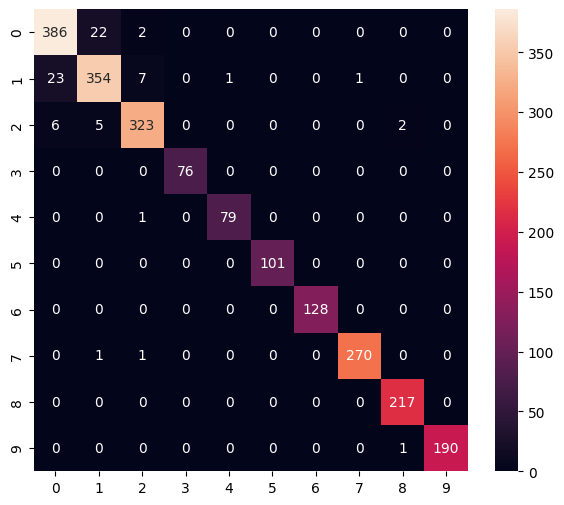

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       410
           1       0.93      0.92      0.92       386
           2       0.97      0.96      0.96       336
           3       1.00      1.00      1.00        76
           4       0.99      0.99      0.99        80
           5       1.00      1.00      1.00       101
           6       1.00      1.00      1.00       128
           7       1.00      0.99      0.99       272
           8       0.99      1.00      0.99       217
           9       1.00      0.99      1.00       191

    accuracy                           0.97      2197
   macro avg       0.98      0.98      0.98      2197
weighted avg       0.97      0.97      0.97      2197



In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g', square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

print_confusion_matrix(y_test, y_pred)

## Convert to TensorFlow Lite

In [30]:
# Save as HDF5
model.save(model_save_path, include_optimizer=False)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)
print(f"TFLite model saved to: {tflite_save_path}")

INFO:tensorflow:Assets written to: C:\Users\GURURA~1\AppData\Local\Temp\tmp3mfawix2\assets


INFO:tensorflow:Assets written to: C:\Users\GURURA~1\AppData\Local\Temp\tmp3mfawix2\assets


Saved artifact at 'C:\Users\GURURA~1\AppData\Local\Temp\tmp3mfawix2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7, 7, 3), dtype=tf.float32, name='keras_tensor_58')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2525308538368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431796960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431797840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431798192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431804528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431805408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431802240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431844880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431843472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2525431843648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  25

## Inference Test

In [31]:
# Test with TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test prediction
test_input = X_test[0:1].astype(np.float32)  # Convert to FLOAT32
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
result = interpreter.get_tensor(output_details[0]['index'])
print(f"Prediction: {np.argmax(result)}")
print(f"Probabilities: {result}")

Prediction: 1
Probabilities: [[2.6303790e-06 9.9990869e-01 8.8634661e-05 1.3782151e-08 3.3779188e-09
  5.8581455e-13 1.3166662e-11 1.0809308e-10 1.7053419e-12 4.5774945e-13]]


c:\Users\Gururamdas\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Summary

This ViT-based classifier provides:
1. **Self-attention mechanism** - Captures relationships between all hand keypoints
2. **2D grid representation** - Preserves spatial structure of hand landmarks
3. **Transformer encoder** - Enables modeling of complex hand configurations
4. **Real-time inference** - Converted to TFLite for efficient deployment